# Transfer Learning avec PyTorch — classification des maladies du haricot (Beans)

Ce notebook est une **démonstration complète** (ce n'est plus un exercice) du **transfer learning** en PyTorch.

Les fonctions utilitaires (`train_net`, `evaluate`, `plot_training_history`, `model_predict`) sont fournies pour adaptations si nécessaires.

**Jeu de données : [Beans](https://huggingface.co/datasets/AI-Lab-Makerere/beans)**. Il s'agit de photos de feuilles de haricot, à classer en 3 catégories : `angular_leaf_spot`, `bean_rust` ou `healthy` (saine). Ce jeu de données a été collecté par le Makerere AI Lab (Ouganda).

**Modèle pré-entraîné : ResNet18** (poids ImageNet), via `torchvision.models`.


In [1]:
# Importer les librairies
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader

import torchvision.models as tv_models
import torchvision.transforms as T
from torchvision.models import ResNet18_Weights

from datasets import load_dataset # À installer avec pip ou uv selon votre system de management de packets
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

# Notre module utilitaire
from pytorch_utils import (
    FastImageFolder,
    train_net,
    evaluate,
    plot_training_history,
    model_predict,
    plot_predictions_grid,
)

### <font color='blue'>Charger et explorer le jeu de données Beans</font>

Le jeu de données Beans est fourni avec des splits `train` / `validation` / `test` déjà définis. Il est téléchargé une fois via la librairie `datasets` (Hugging Face), puis **exporté sur disque** sous forme d'un dossier d'images classées par catégorie (`data/beans/<split>/<classe>/*.jpg`).

Ce format — un dossier par split, un sous-dossier par classe, des images à l'intérieur — est le format **standard** pour organiser son propre jeu de données d'images en PyTorch. Nous le chargeons ensuite avec `FastImageFolder` qui est dérivé de `torchvision.datasets.ImageFolder`. C'est aussi la façon la plus robuste de procéder : `ImageFolder` est une classe de torchvision (donc importable par les processus workers du DataLoader).

Comme nous réutilisons un backbone **pré-entraîné sur ImageNet**, les images doivent être :
* redimensionnées à **224×224** (taille d'entrée native de ResNet18/ImageNet),
* normalisées avec les statistiques **ImageNet** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) puisque ce sont ces statistiques que le modèle pré-entraîné attend.

In [2]:
# Télécharger le jeu de données (une seule fois) via la librairie "datasets" (Hugging Face)
# Pour plus de details sur le jeu de données : https://huggingface.co/datasets/AI-Lab-Makerere/beans
hf_beans = load_dataset("AI-Lab-Makerere/beans")
class_names = hf_beans["train"].features["labels"].names
print(f"Classes : {class_names}")

# Exporter chaque split sur disque, dans un dossier par classe (format "ImageFolder")
DATA_DIR = Path("data/beans")

def export_split_to_disk(hf_split, class_names, split_dir):
    if split_dir.exists() and any(split_dir.iterdir()):
        print(f"{split_dir} existe déjà, export ignoré.")
        return
    for name in class_names:
        (split_dir / name).mkdir(parents=True, exist_ok=True)
    for idx, item in enumerate(hf_split):
        img = item["image"].convert("RGB")
        class_name = class_names[item["labels"]]
        img.save(split_dir / class_name / f"{idx:04d}.jpg")

for split_name, hf_split in hf_beans.items():
    export_split_to_disk(hf_split, class_names, DATA_DIR / split_name)
    print(f"{split_name} : {len(hf_split)} images -> {DATA_DIR / split_name}")

Classes : ['angular_leaf_spot', 'bean_rust', 'healthy']
train : 1034 images -> data/beans/train
validation : 133 images -> data/beans/validation
test : 128 images -> data/beans/test


In [3]:
# Recharger les images depuis le disque avec ImageFolder — c'est ce Dataset,
# picklable et importable, qui sera utilisé pour l'entraînement.
mean, std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean, std),
])
eval_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

train_set = FastImageFolder(DATA_DIR / "train", transform=train_tf)
val_set = FastImageFolder(DATA_DIR / "validation", transform=eval_tf)
test_set = FastImageFolder(DATA_DIR / "test", transform=eval_tf)

# ImageFolder attribue les classes par ordre alphabétique des noms de dossiers :
# on l'utilise comme référence canonique (elle coïncide ici avec l'ordre du jeu de données Hugging Face).
class_names = train_set.classes
print(f"Classes (ImageFolder) : {class_names}")
print(f"Train : {len(train_set)}  Validation : {len(val_set)}  Test : {len(test_set)}")

Classes (ImageFolder) : ['angular_leaf_spot', 'bean_rust', 'healthy']
Train : 1034  Validation : 133  Test : 128


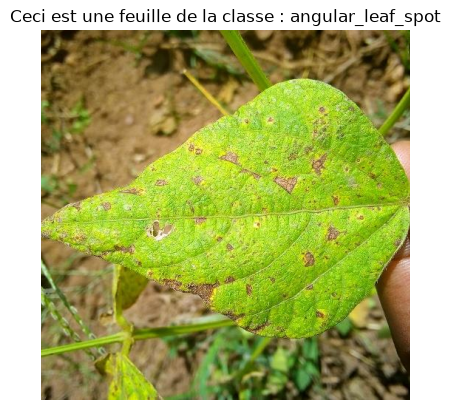

In [4]:
# Explorer le jeu de donnée (image brute, avant transformation/normalisation)
index_img = 12
img_path, label = train_set.samples[index_img]
plt.imshow(Image.open(img_path))
plt.title("Ceci est une feuille de la classe : " + class_names[label])
plt.axis("off")
plt.show()

### <font color='blue'>Transfer Learning : ResNet18 pré-entraîné</font>

Nous chargeons **ResNet18** avec ses poids pré-entraînés sur ImageNet, puis :
* nous **gelons** le backbone convolutif (`requires_grad = False`) pour qu'il ne soit pas modifié durant l'entraînement,
* nous remplaçons la couche entièrement connectée (`fc`) par une nouvelle tête adaptée à nos 3 classes,
* optionnellement, nous **dégelons** le dernier bloc résiduel (`layer4`) pour le fine-tuning : ses filtres, plus spécialisés/haut niveau, sont alors légèrement réajustés à notre jeu de données, avec un taux d'apprentissage plus faible pour ne pas détruire ce qui a été appris sur ImageNet.

In [5]:
class TransferResNet18(nn.Module):
    """
    ResNet18 pré-entraîné sur ImageNet, adapté à la classification des maladies du haricot.

    - Le backbone convolutif est gelé par défaut.
    - unfreeze_last_block=True dégèle le dernier bloc résiduel (layer4) pour le fine-tuning.
    - La couche entièrement connectée (fc) est remplacée par un nouveau classifieur.
    """

    def __init__(self, num_classes: int = 3, unfreeze_last_block: bool = False):
        super().__init__()
        self.backbone = tv_models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # Geler tout le backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Dégeler le dernier bloc résiduel si demandé (fine-tuning)
        if unfreeze_last_block:
            for param in self.backbone.layer4.parameters():
                param.requires_grad = True

        # Remplacer la tête entièrement connectée (le nombre de neurones de sortie
        # correspond au nombre de classes de notre jeu de données)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)

In [6]:
# Vérifier le modèle : nombre de paramètres entraînables selon le mode choisi
for unfreeze in (False, True):
    m = TransferResNet18(num_classes=len(class_names), unfreeze_last_block=unfreeze)
    n_total = sum(p.numel() for p in m.parameters())
    n_train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"unfreeze_last_block={unfreeze!s:5}  paramètres entraînables : {n_train:,} / {n_total:,}")

unfreeze_last_block=False  paramètres entraînables : 132,099 / 11,308,611
unfreeze_last_block=True   paramètres entraînables : 8,525,827 / 11,308,611


***
## Partie 1 : fine-tuning (backbone gelé + dernier bloc résiduel dégelé)

Nous dégelons `layer4` (le dernier bloc résiduel de ResNet18) en plus de la nouvelle tête, et utilisons un **taux d'apprentissage faible** (`1e-4`) : les poids pré-entraînés sont modifiés, mais délicatement.

In [7]:
# Entrainer le modèle avec fine-tuning du dernier bloc résiduel
lr_finetune = 1e-4
epochs_finetune = 25
batch_size = 8

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

model_finetune = TransferResNet18(num_classes=len(class_names), unfreeze_last_block=True)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_finetune.parameters()), lr=lr_finetune, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

model_finetune, history_finetune = train_net(
    model_finetune, train_loader, val_loader, epochs_finetune,
    optimizer, criterion, scheduler,
)

Using mps device


/Users/iouattara/dev-space/uvbf/uvbf-dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/25  loss=0.5423  acc=0.7834  val_loss=0.2328  val_acc=0.8872  LR=1.00e-04
Epoch   2/25  loss=0.2844  acc=0.8965  val_loss=0.1819  val_acc=0.9323  LR=1.00e-04
Epoch   3/25  loss=0.1969  acc=0.9294  val_loss=0.1150  val_acc=0.9624  LR=1.00e-04
Epoch   4/25  loss=0.1591  acc=0.9420  val_loss=0.0875  val_acc=0.9624  LR=1.00e-04
Epoch   5/25  loss=0.1676  acc=0.9400  val_loss=0.1196  val_acc=0.9624  LR=1.00e-04
Epoch   6/25  loss=0.1216  acc=0.9613  val_loss=0.1771  val_acc=0.9398  LR=1.00e-04
Epoch   7/25  loss=0.0858  acc=0.9691  val_loss=0.1345  val_acc=0.9398  LR=1.00e-04
Epoch   8/25  loss=0.1257  acc=0.9526  val_loss=0.2561  val_acc=0.9248  LR=1.00e-04
Epoch   9/25  loss=0.0954  acc=0.9720  val_loss=0.1643  val_acc=0.9474  LR=1.00e-04
Epoch  10/25  loss=0.0750  acc=0.9739  val_loss=0.0889  val_acc=0.9549  LR=1.00e-04
Epoch  11/25  loss=0.0504  acc=0.9807  val_loss=0.1190  val_acc=0.9474  LR=1.00e-04
Epoch  12/25  loss=0.0666  acc=0.9768  val_loss=0.1917  val_acc=0.9474  LR=1

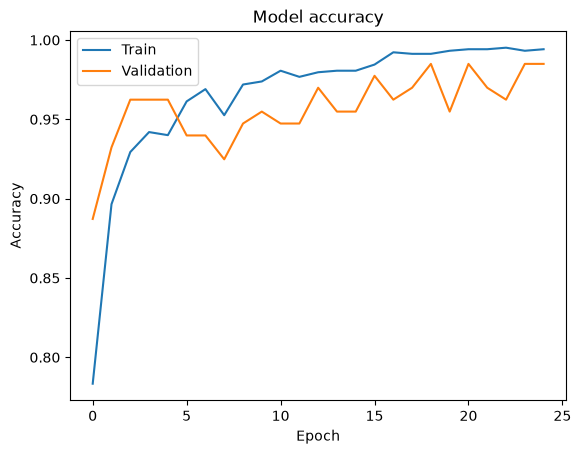

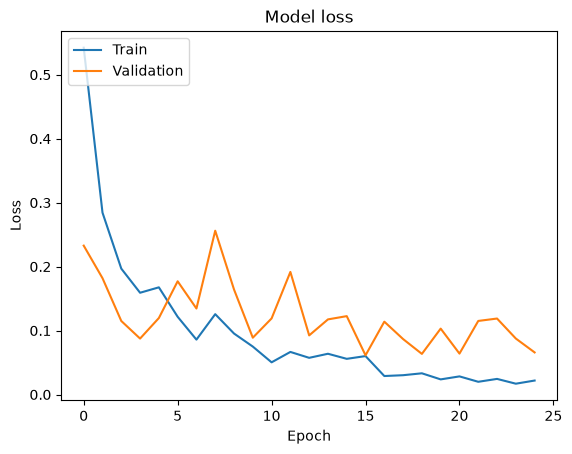

In [8]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
plot_training_history(history_finetune)

Évaluation (fine-tuning) sur le jeu de test :
loss=0.0832  accuracy=0.9688


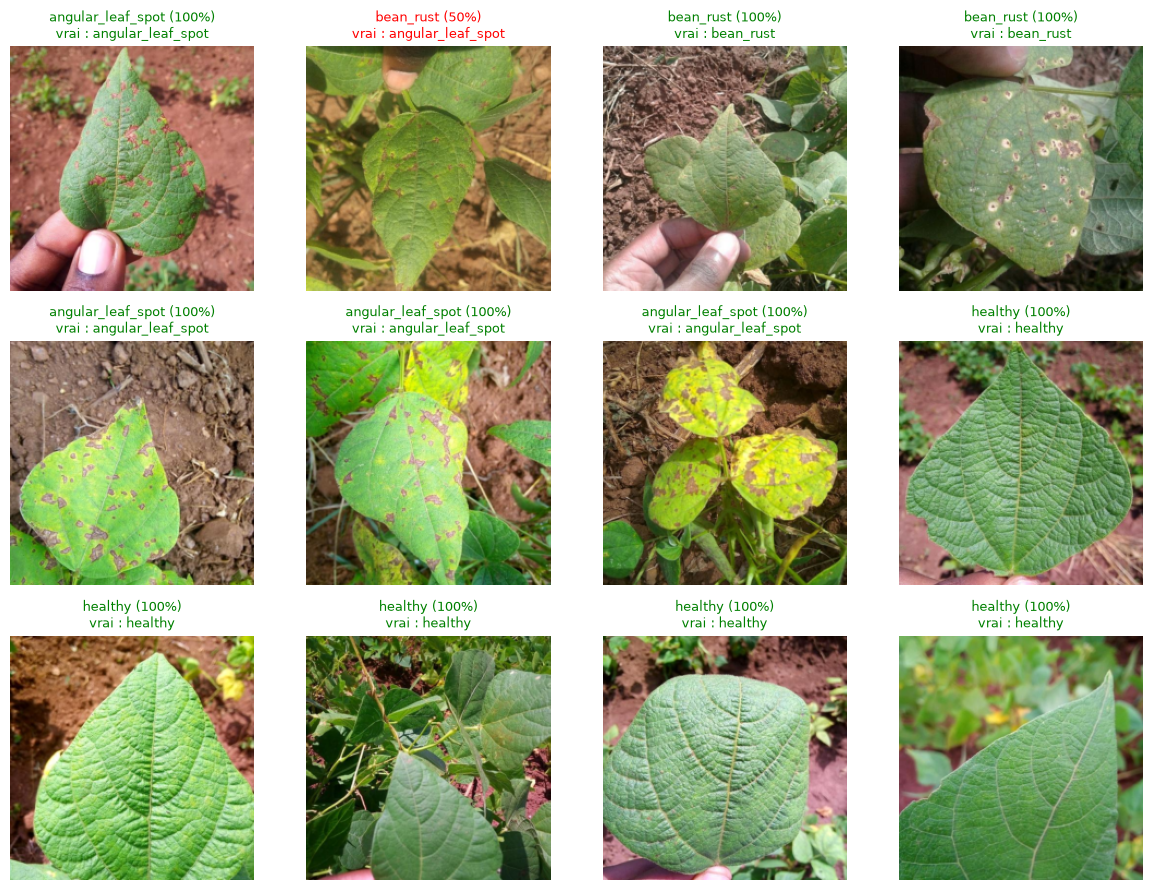

In [9]:
# Évaluer sur le jeu de test
print("Évaluation (fine-tuning) sur le jeu de test :")
loss_finetune, acc_finetune = evaluate(model_finetune, test_set)

# Tester le modèle sur plusieurs images du jeu de test, sous forme de grille
import random
sample_indices = random.sample(range(len(test_set)), 12)
plot_predictions_grid(model_finetune, test_set, sample_indices, class_names, mean=mean, std=std)

***
## Partie 2 : backbone entièrement gelé

Ici, **tout** le backbone ResNet18 reste gelé — seule la nouvelle tête entièrement connectée est entraînée. Comme beaucoup moins de paramètres sont mis à jour, nous pouvons utiliser un taux d'apprentissage plus élevé (`1e-3`).

In [10]:
# Entrainer le modèle avec le backbone entièrement gelé
lr_frozen = 1e-3
epochs_frozen = 25

model_frozen = TransferResNet18(num_classes=len(class_names), unfreeze_last_block=False)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_frozen.parameters()), lr=lr_frozen, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

model_frozen, history_frozen = train_net(
    model_frozen, train_loader, val_loader, epochs_frozen,
    optimizer, criterion, scheduler,
)

Using mps device
Epoch   1/25  loss=0.8575  acc=0.6035  val_loss=0.4868  val_acc=0.8647  LR=1.00e-03
Epoch   2/25  loss=0.6953  acc=0.6857  val_loss=0.4400  val_acc=0.8120  LR=1.00e-03
Epoch   3/25  loss=0.6158  acc=0.7418  val_loss=0.4997  val_acc=0.7594  LR=1.00e-03
Epoch   4/25  loss=0.5744  acc=0.7602  val_loss=0.3329  val_acc=0.8647  LR=1.00e-03
Epoch   5/25  loss=0.5548  acc=0.7679  val_loss=0.3493  val_acc=0.8722  LR=1.00e-03
Epoch   6/25  loss=0.5328  acc=0.7747  val_loss=0.3515  val_acc=0.8571  LR=1.00e-03
Epoch   7/25  loss=0.4689  acc=0.8153  val_loss=0.3567  val_acc=0.8346  LR=1.00e-03
Epoch   8/25  loss=0.4701  acc=0.8133  val_loss=0.3977  val_acc=0.8571  LR=1.00e-03
Epoch   9/25  loss=0.4956  acc=0.7979  val_loss=0.2557  val_acc=0.8872  LR=1.00e-03
Epoch  10/25  loss=0.4630  acc=0.8114  val_loss=0.3121  val_acc=0.8722  LR=1.00e-03
Epoch  11/25  loss=0.4944  acc=0.8008  val_loss=0.4753  val_acc=0.7895  LR=1.00e-03
Epoch  12/25  loss=0.4915  acc=0.7988  val_loss=0.3158  val

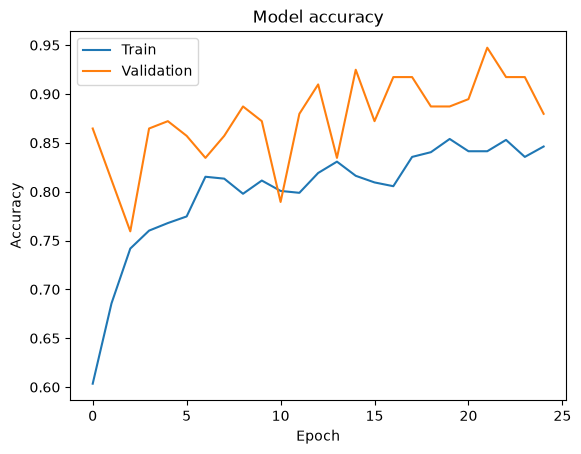

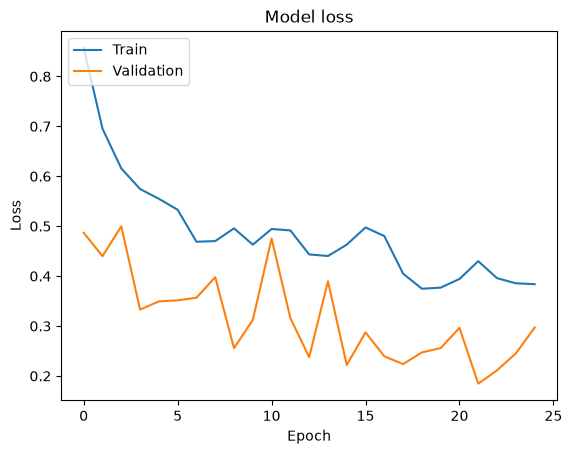

In [11]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
plot_training_history(history_frozen)

Évaluation (backbone gelé) sur le jeu de test :
loss=0.4049  accuracy=0.8281


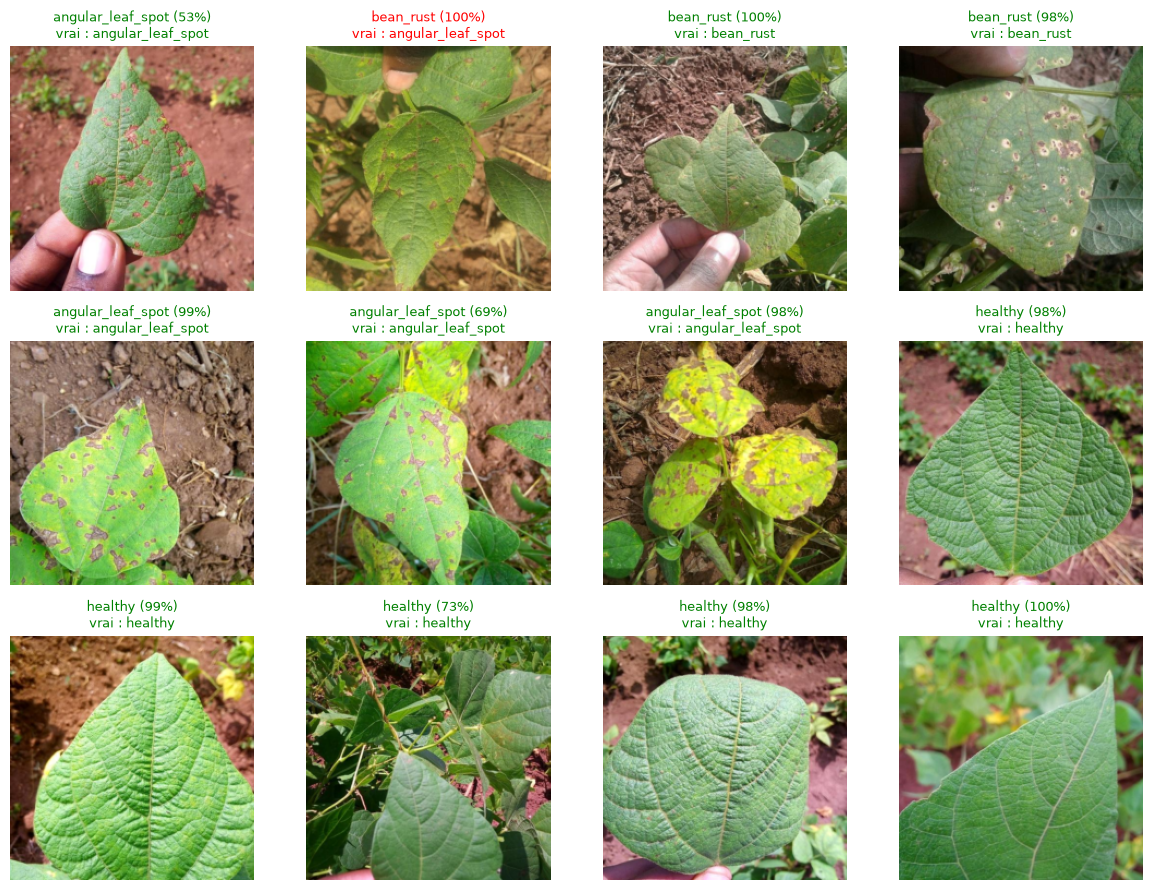

In [12]:
# Évaluer sur le jeu de test
print("Évaluation (backbone gelé) sur le jeu de test :")
loss_frozen, acc_frozen = evaluate(model_frozen, test_set)

# Tester le modèle sur les mêmes images que la Partie 1 (comparaison directe)
plot_predictions_grid(model_frozen, test_set, sample_indices, class_names, mean=mean, std=std)

***
## Comparaison et conclusion

In [13]:
print(f"Fine-tuning (layer4 dégelé)  : loss={loss_finetune:.4f}  accuracy={acc_finetune:.4f}")
print(f"Backbone entièrement gelé     : loss={loss_frozen:.4f}  accuracy={acc_frozen:.4f}")

Fine-tuning (layer4 dégelé)  : loss=0.0832  accuracy=0.9688
Backbone entièrement gelé     : loss=0.4049  accuracy=0.8281


# **Note Important**
* Le **fine-tuning** (dégeler le dernier bloc résiduel) permet généralement au modèle de mieux s'adapter aux spécificités des feuilles de haricot par rapport à ImageNet, au prix d'un entraînement plus coûteux (plus de paramètres à mettre à jour) et d'un risque de sur-apprentissage plus élevé sur un aussi petit jeu de données.
* Le **backbone entièrement gelé** entraîne beaucoup moins de paramètres, donc plus vite, mais peut sous-performer si les caractéristiques ImageNet ne collent pas parfaitement à la tâche.

# **Références**

* Jeu de données Beans : https://huggingface.co/datasets/AI-Lab-Makerere/beans
* Tutoriel PyTorch sur le transfer learning : https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
* Modèles pré-entraînés torchvision : https://docs.pytorch.org/vision/stable/models.html
* Optimiser l'entrainement: https://docs.pytorch.org/tutorials/intermediate/intermediate_data_loading_tutorial.html